In [166]:
import dill
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from ipywidgets import widgets
from ipywidgets import VBox, interactive_output
import numpy as np
import pandas as pd
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from types import SimpleNamespace
from cmcrameri import cm

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["figure.facecolor"] = "None"

In [167]:
import os
import sys
# Change working directory to project root if running from notebooks directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(f"Current Working Directory: {os.getcwd()}")

# Add tools path to import binning function
sys.path.append("tools")
from tools import binning

Current Working Directory: /Volumes/X31/01.Projects/atem

## Workflow Overview

- Set up plotting and notebook dependencies.
- Load ATEM configuration and selected channels.
- Read and normalize the NE survey data.
- Check missing coordinate values by flight line.
- Clean missing values before binning.
- Bin each line at 50 m spacing.
- Map power-line monitor and flight height values.
- Load saved inversion outputs.
- Compare observed and predicted responses by iteration and line.
- Plot resistivity sections by iteration and line.
- Plot resistivity depth slices by iteration, line, and depth.
- Review the inversion trade-off with an L-curve.


In [168]:
area:str = "NW"
tmp:dict = binning(dx=50, area=area)

In [169]:
times = tmp["times"]
values = tmp["values"]
values_std = tmp["values_std"]
soundings = tmp["soundings"]
n_turns = tmp["n_turns"]
dheader = tmp["dheader"]
picker = tmp["picker"]

In [170]:
df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

In [171]:
print(f"Binned soundings: {len(df_data_binned):,}\n")

Binned soundings: 98,552

## Flight-Line Monitor Maps

Map the power-line monitor and flight height values in x-y space.


Text(0.5, 1.0, 'Digital Terrain Model')

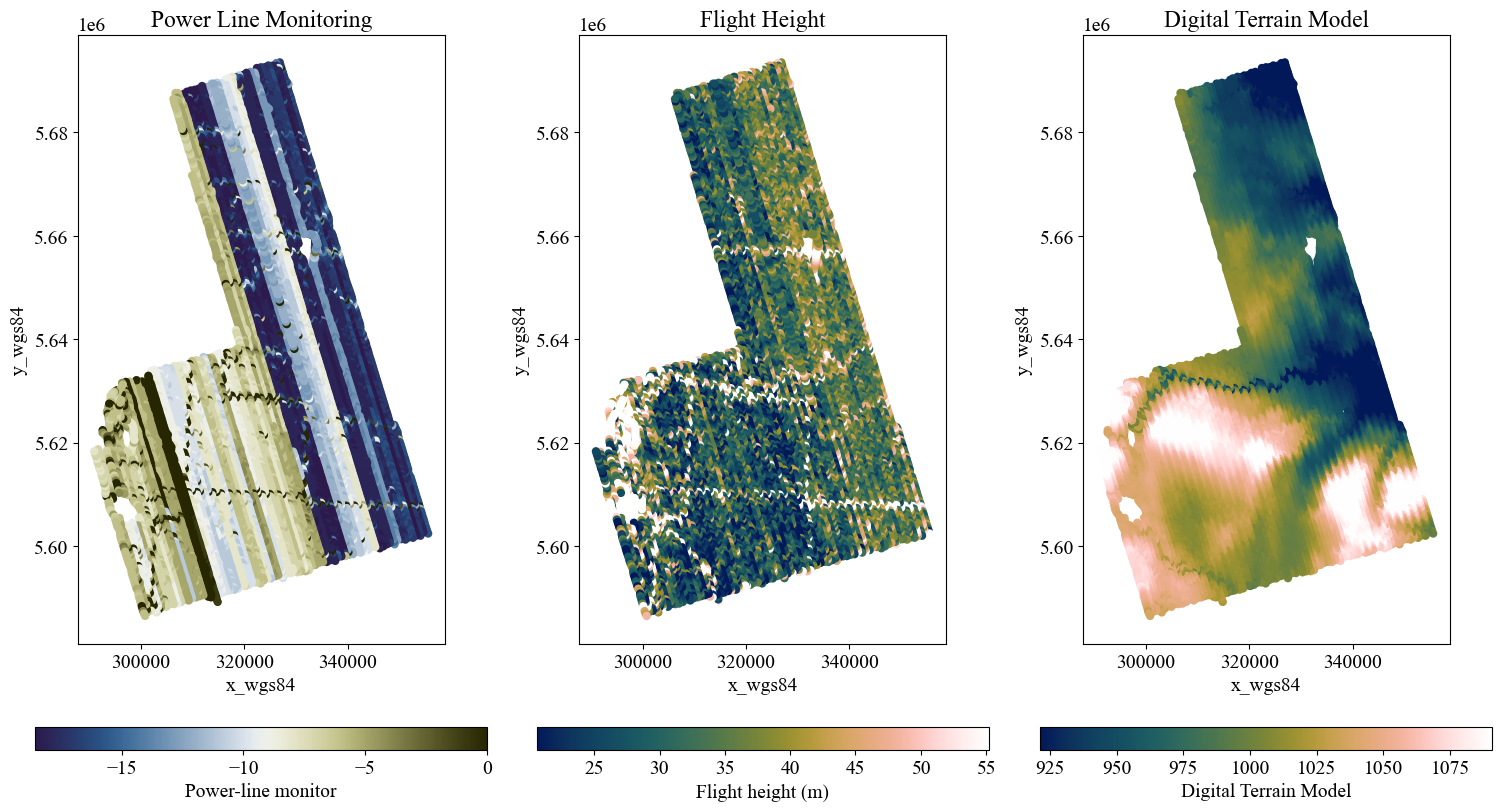

In [172]:
monitor_skip = 10
monitor_index = np.arange(0, len(df_data_binned), monitor_skip)

fig, axs = plt.subplots(1, 3, figsize=(15, 8), constrained_layout=True)
ax1, ax2, ax3 = axs

pwrline_values = df_data_binned['pwrline'].values.astype(float)
bheight_values = df_data_binned['bheight'].values.astype(float)
dtm_values = df_data_binned['dtm'].values.astype(float)
x_values = df_data_binned['x_wgs84'].values.astype(float)
y_values = df_data_binned['y_wgs84'].values.astype(float)

out1 = ax1.scatter(
    x_values[monitor_index],
    y_values[monitor_index],
    c=pwrline_values[monitor_index],
    vmin=np.nanpercentile(pwrline_values[monitor_index], 5),
    vmax=np.nanpercentile(pwrline_values[monitor_index], 95),
    edgecolors='none',
    cmap=cm.broc
)
cb1 = plt.colorbar(out1, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.05)
cb1.set_label('Power-line monitor')
ax1.set_aspect(1)
ax1.set_xlabel('x_wgs84')
ax1.set_ylabel('y_wgs84')
ax1.set_title('Power Line Monitoring')

out2 = ax2.scatter(
    x_values[monitor_index],
    y_values[monitor_index],
    c=bheight_values[monitor_index],
    vmin=np.nanpercentile(bheight_values[monitor_index], 5),
    vmax=np.nanpercentile(bheight_values[monitor_index], 95),
    cmap=cm.batlowW,
    edgecolors='none',
)
cb2 = plt.colorbar(out2, ax=ax2, orientation='horizontal', fraction=0.05, pad=0.05)
cb2.set_label('Flight height (m)')
ax2.set_aspect(1)
ax2.set_xlabel('x_wgs84')
ax2.set_ylabel('y_wgs84')
ax2.set_title('Flight Height')

out3 = ax3.scatter(
    x_values[monitor_index],
    y_values[monitor_index],
    c=dtm_values[monitor_index],
    vmin=np.nanpercentile(dtm_values[monitor_index], 5),
    vmax=np.nanpercentile(dtm_values[monitor_index], 95),
    cmap=cm.batlowW,
    edgecolors='none',
)
cb3 = plt.colorbar(out3, ax=ax3, orientation='horizontal', fraction=0.05, pad=0.05)
cb3.set_label('Digital Terrain Model')
ax3.set_aspect(1)
ax3.set_xlabel('x_wgs84')
ax3.set_ylabel('y_wgs84')
ax3.set_title('Digital Terrain Model')

In [173]:
n_time = len(times)
dobs = df_data_binned[dheader].values.flatten() # Binned Data

In [174]:
!pwd

/Volumes/X31/01.Projects/atem


In [175]:
# name:str = "../data/inv_results_atem_full.pik"
# name:str = "../data/inv_results_atem_full_2.pik"
name:str = f"./data/{area}_inv_results_atem_full.pik"
outDict:dict = dill.load(open(name, "rb"))
print(outDict.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [176]:
print(outDict[1])

{
    'iter': 1,
    'beta': 7498.655274045995,
    'phi_d': 239299455.16118544,
    'phi_m': 5109.007042044494,
    'f': 1111832107.4139733,
    'm': array([-2.72848408, -2.72561698, -2.72154721, ..., -2.34876548,
       -2.34570456, -2.34435129]),
    'dpred': array([-4.56676548e-10, -3.78345633e-10, -3.02853188e-10, ...,
       -4.76356969e-11, -3.91454671e-11, -3.20254318e-11]),
    'SparseSmallness.irls_threshold': 1e-08,
    'SparseSmallness.norm': 1,
    'r LaterallyConstrainedSmoothness.irls_threshold': 1e-08,
    'r LaterallyConstrainedSmoothness.norm': 1,
    'z LaterallyConstrainedSmoothness.irls_threshold': 1e-08,
    'z LaterallyConstrainedSmoothness.norm': 1
}

In [177]:
iterations = len(outDict.keys())
print(f"{iterations=}")

iterations=20

In [178]:
topography = df_data_binned[['x_wgs84','y_wgs84', 'dtm']].values
source_heights = df_data_binned['bheight'].values
thickness = get_vertical_discretization(21, 2, 1.17)

>> Depth from the surface to the base of the bottom layer is 306.3m


In [179]:
print(topography.dtype)
print(topography[:,0].max())
print(topography.dtype)
print(np.asarray(topography[:,0]).max())

object

355580.9380159481

object

355580.9380159481

In [180]:
np.asarray(topography[:,0],dtype=float).max()

355580.9380159481

Text(0.5, 1.0, 'Negative source heights (bheight) in the binned data (tie-lines)')

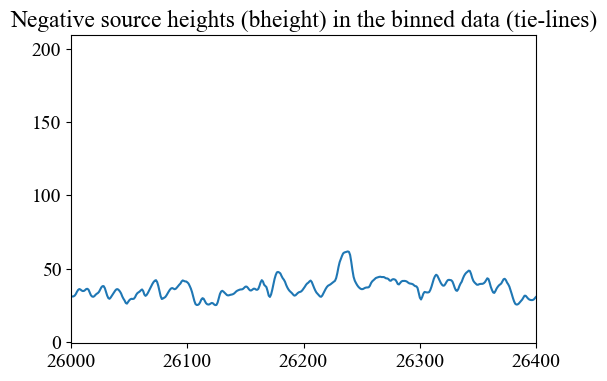

In [181]:
plt.plot(source_heights)
plt.xlim(26000,26400)
plt.title("Negative source heights (bheight) in the binned data (tie-lines)")

In [182]:

input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "times":times,    
}
inp = SimpleNamespace(**input_data_dict)

In [183]:
line_no = list(df_data_binned['Line'].unique())

In [184]:
line = np.array([int(str(val).strip('L').strip('T')) for val in df_data_binned['Line'].values])
unique_line_values = np.unique(line)
line_name_values = [str(val) for val in line_no]

n_sounding = len(line)

## Depth slice map

- Plot the inverted resistivity model at a selected depth layer in `x_wgs84` / `y_wgs84` coordinates.
- And compare the difference between each iteration.


In [185]:
inp.topography[:,0].max()

355580.9380159481

In [186]:
from scipy.spatial import cKDTree as KDTree
from matplotlib.colors import LogNorm

# Grid and interpolation settings for resistivity depth-slice maps.
map_dx = 100.0
map_dy = 100.0
x_pad = 1000.0
y_pad = 1000.0
k_nearest_points = 100
max_distance = 500.0
idw_power = 0.0

xy_model = inp.topography[:, :2]
xmin, xmax = xy_model[:, 0].astype(object).min() - x_pad, xy_model[:, 0].astype(object).max() + x_pad
ymin, ymax = xy_model[:, 1].astype(object).min() - y_pad, xy_model[:, 1].astype(object).max() + y_pad

nx = int((xmax - xmin) / map_dx)
ny = int((ymax - ymin) / map_dy)
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

map_tree = KDTree(xy_model)
distances_idw, indices_idw = map_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()],
    k=int(k_nearest_points),
)

idw_epsilon = min(map_dx, map_dy)
idw_weights = 1.0 / ((distances_idw + idw_epsilon) ** idw_power)
nearest_distance, _ = map_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance

hz = np.r_[thickness, thickness[-1]]
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])
n_layer = len(hz)

In [187]:
# Store distance information for each line
distance_by_line = {}
for i_line, line in enumerate(line_no):
    line_start_idx = sum(soundings[:i_line])
    line_end_idx = line_start_idx + soundings[i_line]
    distance_by_line[line] = df_data_binned.iloc[line_start_idx:line_end_idx]['distance'].values

In [188]:
def plot_combined_map_and_line(i_iteration, line_name, i_depth):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # --- Left: Depth Slice Map ---
    m_iter = np.asarray(outDict[i_iteration]['m'])
    rho_iter = 1.0 / np.exp(m_iter)
    rho_layers = rho_iter.reshape((n_sounding, n_layer))

    values = rho_layers[:, i_depth]
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_grid = values[indices_idw]
    values_grid[mask_outside_data] = np.nan
    values_grid = values_grid.reshape(X_map.shape)

    selected_line = df_data_binned[df_data_binned['Line'].astype(str) == str(line_name)]
    if selected_line.empty:
        raise ValueError(f"No data found for line {line_name}")

    out = ax1.pcolormesh(
        x_map,
        y_map,
        values_grid,
        cmap='turbo',
        norm=LogNorm(vmin=8, vmax=60),
        shading='auto',
    )
    ax1.plot(xy_model[:, 0], xy_model[:, 1], 'k,', alpha=0.12)
    ax1.plot(
        selected_line['x_wgs84'],
        selected_line['y_wgs84'],
        color='white',
        linewidth=2.0,
    )
    ax1.plot(
        selected_line['x_wgs84'],
        selected_line['y_wgs84'],
        color='black',
        linewidth=0.8,
    )
    ax1.scatter(
        selected_line['x_wgs84'].iloc[0],
        selected_line['y_wgs84'].iloc[0],
        s=30,
        color='white',
        edgecolor='black',
        zorder=5,
    )

    cb = plt.colorbar(out, ax=ax1, orientation='vertical')
    cb.set_label('Resistivity (ohm-m)')
    ax1.set_xlabel('x_wgs84')
    ax1.set_ylabel('y_wgs84')
    ax1.set_aspect(1)
    ax1.set_title(
        f"Iteration {i_iteration}, Line {line_name}, "
        f"Depth {depth_centers[i_depth]:.1f} m"
    )
    ax1.grid(True, alpha=0.15)
    
    # --- Right: Data Line Plot ---
    i_line_num = line_no.index(line_name)
    
    line_start_idx = sum(soundings[:i_line_num])
    n_soundings_in_line = soundings[i_line_num]
    
    DPRED = outDict[i_iteration]['dpred'].reshape((-1, n_time))
    DOBS = dobs.reshape((-1, n_time))
    
    distances = distance_by_line[line_name]
    
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    
    for i_time in range(n_time):
        dpred_line = -DPRED[line_start_idx:line_start_idx + n_soundings_in_line, i_time]
        dobs_line = -DOBS[line_start_idx:line_start_idx + n_soundings_in_line, i_time]
        
        dpred_sorted = dpred_line[sort_idx]
        dobs_sorted = dobs_line[sort_idx]
        
        ax2.plot(distances_sorted, dpred_sorted, '-', linewidth=1.5, alpha=0.7, label=f'T{i_time}')
        ax2.plot(distances_sorted, dobs_sorted, 'k--', linewidth=1, alpha=0.5)
    
    ax2.set_yscale('log')
    ax2.set_xlabel('Distance along line (m)')
    ax2.set_ylabel('|dB/dt| (V/A/m²)')
    ax2.legend(ncol=2, fontsize=8)
    ax2.grid(False)
    ax2.set_title(f"Iteration {i_iteration}, Line {line_name}")
    
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

iter_depth_slider = widgets.IntSlider(
    min=1,
    max=iterations,
    step=1,
    value=1,
    description='Iteration:',
    continuous_update=False,
)
line_slider = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description='Line:',
)
depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description='Depth:',
    continuous_update=False,
)

combined_output = interactive_output(
    plot_combined_map_and_line,
    {
        'i_iteration': iter_depth_slider,
        'line_name': line_slider,
        'i_depth': depth_slider,
    },
)

VBox([iter_depth_slider, line_slider, depth_slider, combined_output])


In [189]:
def min_max_scaler(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    if max_val - min_val == 0:
        return np.zeros_like(arr)  # Avoid division by zero, return zeros if all values are the same
    scaled_arr = (arr - min_val) / (max_val - min_val)
    return scaled_arr


In [190]:
print(f"{n_sounding=:,}")
print(f"{len(soundings)=:,}")

n_sounding=98,552

len(soundings)=118

In [191]:
def compute_line_directional_ratios_by_depth(i_iteration, opt="C1"):
    rho_iter = 1.0 / np.exp(outDict[i_iteration - 1]["m"])
    rho_next = 1.0 / np.exp(outDict[i_iteration]["m"])
    rho_layers_iter = rho_iter.reshape((n_sounding, n_layer))
    rho_layers_next = rho_next.reshape((n_sounding, n_layer))

    # Basis vector: First line (soundings[0]) direction is used.
    first_line_xy = xy_model[:soundings[0]]
    first_line_vec = first_line_xy[-1] - first_line_xy[0]
    first_line_angle = np.arctan2(first_line_vec[1], first_line_vec[0])
    along_u = np.array([np.cos(first_line_angle), np.sin(first_line_angle)])
    perp_u = np.array([-np.sin(first_line_angle), np.cos(first_line_angle)])

    depth_ratios = []
    for i_depth in range(n_layer):
        values_iter = rho_layers_iter[:, i_depth]
        values_next = rho_layers_next[:, i_depth]
        values_diff = values_next - values_iter

        values_diff_grid = np.sum(idw_weights * values_diff[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
        # values_diff_grid = values_diff[indices_idw]
        values_diff_grid[mask_outside_data] = np.nan
        values_diff_grid = values_diff_grid.reshape(X_map.shape)

        dy_grid, dx_grid = np.gradient(values_diff_grid, y_map, x_map)

        if opt =="C1":
            along_proj = np.nanmean(np.abs(dx_grid * along_u[0] + dy_grid * along_u[1]))
            perp_proj = np.nanmean(np.abs(dx_grid * perp_u[0] + dy_grid * perp_u[1]))
            depth_ratios.append(perp_proj / along_proj)

        if opt =="C2":
            # L2-norm of projections onto along and perpendicular directions
            along_proj = np.sqrt(np.nanmean((dx_grid * along_u[0] + dy_grid * along_u[1])**2))
            perp_proj = np.sqrt(np.nanmean((dx_grid * perp_u[0] + dy_grid * perp_u[1])**2))
            depth_ratios.append(perp_proj / along_proj)

        if opt == "C3":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            along_proj[along_proj <= 1e-10] = np.inf
            ratio = np.nanmean(np.abs(perp_proj / along_proj))
            depth_ratios.append(ratio)

        if opt == "C4":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            along_proj[along_proj <= 1e-10] = np.inf
            ratio = np.sqrt(np.nanmean((perp_proj / along_proj)**2))
            depth_ratios.append(ratio)
        
        if opt == "C5":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            depth_ratios.append(
                np.nanmean(
                    ( - (along_proj)**2 + (perp_proj)**2)/((along_proj)**2 + (perp_proj)**2 + 1e-10)
                )
            )


    return np.array(depth_ratios)


In [192]:
ratio_matrix_A = np.vstack([compute_line_directional_ratios_by_depth(i, opt="C5") for i in range(2, iterations + 1)])

In [193]:
def plot_ratio_by_depth(depth_index=0):
    iters = np.arange(2, iterations + 1)
    ratio_values = ratio_matrix_A[:, depth_index]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.plot(iters, ratio_values, marker='o', color='tab:blue', linewidth=2.5, markersize=8)
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Perp/Along Ratio', fontsize=12, fontweight='bold')
    ax.set_title(f'Depth {depth_centers[depth_index]:.1f} m: Perp/Along Ratio by Iteration', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(np.nanmin(ratio_values)*1.1, np.nanmax(ratio_values) * 1.1)
    plt.show()

depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description='Depth:',
    continuous_update=False,
)

ratio_output = interactive_output(
    plot_ratio_by_depth,
    {'depth_index': depth_slider},
)

VBox([depth_slider, ratio_output])


In [194]:
def plot_iteration_resistivity_comparison(i_iteration, i_depth):
    """Plot resistivity maps for iteration i, i+1, and their difference."""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Get resistivity for both iterations
    rho_iter = 1.0 / np.exp(outDict[i_iteration - 1]["m"])
    rho_next = 1.0 / np.exp(outDict[i_iteration]["m"])
    
    rho_layers_iter = rho_iter.reshape((n_sounding, n_layer))
    rho_layers_next = rho_next.reshape((n_sounding, n_layer))
    
    values_iter = rho_layers_iter[:, i_depth]
    values_next = rho_layers_next[:, i_depth]
    values_diff = values_next - values_iter
    
    # Interpolate to grid
    values_iter_grid = np.sum(idw_weights * values_iter[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_iter_grid = values_iter[indices_idw]
    values_iter_grid[mask_outside_data] = np.nan
    values_iter_grid = values_iter_grid.reshape(X_map.shape)
    
    values_next_grid = np.sum(idw_weights * values_next[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_next_grid = values_next[indices_idw]
    values_next_grid[mask_outside_data] = np.nan
    values_next_grid = values_next_grid.reshape(X_map.shape)
    
    values_diff_grid = np.sum(idw_weights * values_diff[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_diff_grid = values_diff[indices_idw]
    values_diff_grid[mask_outside_data] = np.nan
    values_diff_grid = values_diff_grid.reshape(X_map.shape)
    
    # Plot iteration i
    out1 = ax1.pcolormesh(x_map, y_map, values_iter_grid, cmap="turbo", norm=LogNorm(vmin=8, vmax=60), shading="auto")
    ax1.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax1.set_aspect(1)
    ax1.set_title(f"Iteration {i_iteration - 1}, Depth {depth_centers[i_depth]:.1f} m")
    ax1.set_xlabel("x_wgs84")
    ax1.set_ylabel("y_wgs84")
    plt.colorbar(out1, ax=ax1, label="Resistivity (Ω·m)")
    
    # Plot iteration i+1
    out2 = ax2.pcolormesh(x_map, y_map, values_next_grid, cmap="turbo", norm=LogNorm(vmin=8, vmax=60), shading="auto")
    ax2.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax2.set_aspect(1)
    ax2.set_title(f"Iteration {i_iteration}, Depth {depth_centers[i_depth]:.1f} m")
    ax2.set_xlabel("x_wgs84")
    ax2.set_ylabel("y_wgs84")
    plt.colorbar(out2, ax=ax2, label="Resistivity (Ω·m)")
    
    # Plot difference
    vmax_diff = np.nanmax(np.abs(values_diff_grid))
    out3 = ax3.pcolormesh(x_map, y_map, values_diff_grid, cmap="RdBu_r", vmin=-vmax_diff, vmax=vmax_diff, shading="auto")
    ax3.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax3.set_aspect(1)
    ax3.set_title(f"Difference (Iter {i_iteration} - Iter {i_iteration - 1})")
    ax3.set_xlabel("x_wgs84")
    ax3.set_ylabel("y_wgs84")
    plt.colorbar(out3, ax=ax3, label="ΔResistivity (Ω·m)")
    # plt.colorbar(out3, ax=ax3, label="Normalized ΔResistivity (Ω·m)")
    
    plt.tight_layout()
    plt.show()

iter_slider = widgets.IntSlider(
    min=2,
    max=iterations,
    step=1,
    value=2,
    description="Iteration:",
    continuous_update=False,
)

iter_depth_slider_comp = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

iter_comparison_output = interactive_output(
    plot_iteration_resistivity_comparison,
    {"i_iteration": iter_slider, "i_depth": iter_depth_slider_comp},
)

VBox([iter_slider, iter_depth_slider_comp, iter_comparison_output])

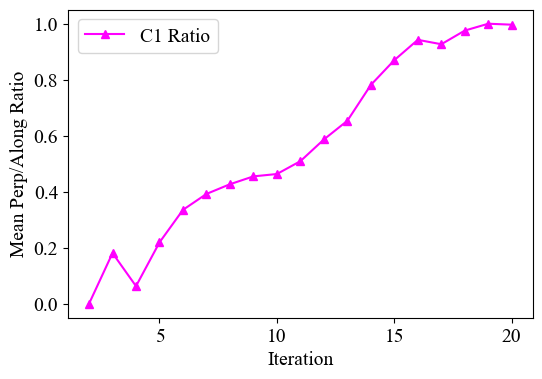

In [195]:
plt.plot([it for it in range(2, iterations + 1)], min_max_scaler(np.mean(ratio_matrix_A, axis=1)), c='magenta', marker='^')
# plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Mean Perp/Along Ratio')
plt.legend(['C1 Ratio', 'C2 Ratio', 'C3 Ratio', 'C4 Ratio', 'C5 Ratio'])

In [196]:
def plot_monitor_and_inversion_by_depth(i_depth, i_iteration=None):
    if i_iteration is None:
        i_iteration = iterations

    if i_depth < 0 or i_depth >= n_layer:
        raise ValueError(f"i_depth must be in [0, {n_layer - 1}]")

    # 1) Prepare scalar fields at sounding locations.
    monitor_fields = {
        "pwrline": df_data_binned["pwrline"].values.astype(float),
        "bheight": df_data_binned["bheight"].values.astype(float),
        "dtm": df_data_binned["dtm"].values.astype(float),
    }

    # 2) Build inversion depth slice on the interpolation grid.
    m_iter = np.asarray(outDict[i_iteration]["m"])
    rho_iter = 1.0 / np.exp(m_iter)
    rho_layers = rho_iter.reshape((n_sounding, n_layer))
    values = rho_layers[:, i_depth]
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    values_grid[mask_outside_data] = np.nan
    values_grid = values_grid.reshape(X_map.shape)

    # Even larger figure + tighter spacing between panels.
    fig, axes = plt.subplot_mosaic(
        [["pwrline", "bheight", "dtm", "inversion"]],
        figsize=(20, 6),
        constrained_layout=False,
    )

    # Keep colorbars clearly separated from x-axis labels.
    cbar_fraction = 0.035
    cbar_pad = 0.15

    # 3) Plot monitor-related fields at sounding locations.
    cma = [cm.broc, cm.batlowW, cm.batlowW]
    for i, name in enumerate(["pwrline", "bheight", "dtm"]):
        field_values = monitor_fields[name]
        vmin = np.nanpercentile(field_values, 5)
        vmax = np.nanpercentile(field_values, 95)
        sc = axes[name].scatter(
            xy_model[:, 0],
            xy_model[:, 1],
            c=field_values,
            cmap=cma[i],
            vmin=vmin,
            vmax=vmax,
            s=3,
            edgecolors="none",
        )
        axes[name].set_aspect(1)
        axes[name].set_xlabel("x_wgs84")
        axes[name].set_ylabel("y_wgs84")
        axes[name].set_title(name)
        plt.colorbar(
            sc,
            ax=axes[name],
            orientation="horizontal",
            fraction=cbar_fraction,
            pad=cbar_pad,
        )

    # 4) Plot inversion map for selected depth.
    im = axes["inversion"].pcolormesh(
        x_map,
        y_map,
        values_grid,
        cmap="turbo",
        # cmap=cm.batlow,
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto"
    )
    # axes["inversion"].plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    axes["inversion"].set_aspect(1)
    axes["inversion"].set_xlabel("x_wgs84")
    axes["inversion"].set_ylabel("y_wgs84")
    axes["inversion"].set_title(
        f"inversion | iter={i_iteration}, depth={depth_centers[i_depth]:.1f} m"
    )
    plt.colorbar(
        im,
        ax=axes["inversion"],
        label="Resistivity (ohm-m)",
        orientation="horizontal",
        fraction=cbar_fraction,
        pad=cbar_pad,
    )

    plt.suptitle("Monitor fields and inversion depth slice", y=0.98)
    plt.subplots_adjust(left=0.035, right=0.8, bottom=0.2, top=0.88, wspace=0.005)
    plt.show()


iter_slider_map = widgets.IntSlider(
    min=1,
    max=iterations,
    step=1,
    value=1,
    description="Iteration:",
    continuous_update=False,
)

depth_slider_map = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

depth_map_output = interactive_output(
    plot_monitor_and_inversion_by_depth,
    {"i_depth": depth_slider_map, "i_iteration": iter_slider_map},
)

VBox([iter_slider_map, depth_slider_map, depth_map_output])

In [197]:
phi_d = [outDict[i]['phi_d'] for i in range(1, iterations + 1)]
phi_m = [outDict[i]['phi_m'] for i in range(1, iterations + 1)]
no_of_data_points = outDict[1]['dpred'].shape[0]
chi_squared = np.array(phi_d) / no_of_data_points
print(f"chi squared: {chi_squared}")

chi squared: [110.37064658  25.62945709  11.74540045   7.81740354   6.87948411
   6.33750265   3.97419717   3.21340521   2.56040489   1.25735054
   1.03673686   0.79480511   0.54099239   0.47280675   0.37152263
   0.25824895   0.241332     0.2166274    0.18845381   0.18235765]

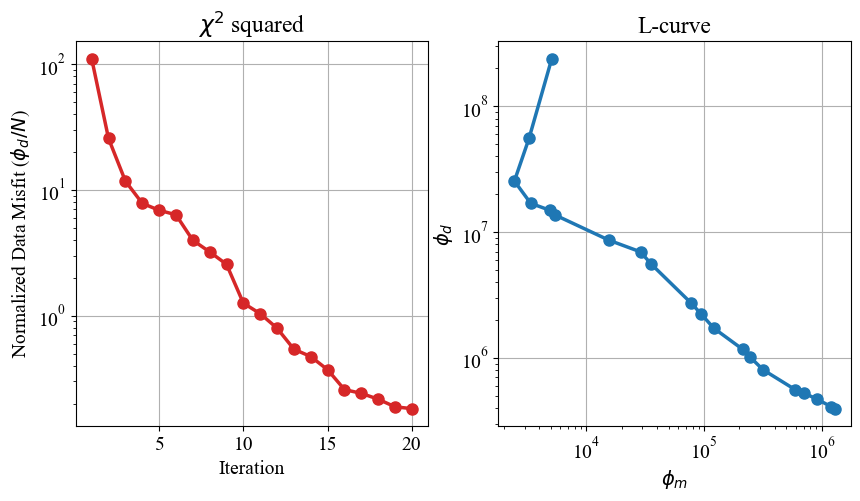

In [198]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, iterations + 1), chi_squared, marker='o', color='tab:red', linewidth=2.5, markersize=8)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Normalized Data Misfit ($\phi_d / N$)')
plt.title("$\chi^2$ squared")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(phi_m, phi_d, marker='o', color='tab:blue', linewidth=2.5, markersize=8)
plt.xscale('log')
plt.yscale('log')
plt.title("L-curve")
plt.xlabel("$\phi_m$")
plt.ylabel("$\phi_d$")
plt.grid()

In [ ]:
def _compute_cell_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - (mids[0] - values[0])
    right = values[-1] + (values[-1] - mids[-1])
    return np.r_[left, mids, right]


def _moving_average_nan_1d(arr, window):
    if window <= 1:
        return arr
    kernel = np.ones(window, dtype=float)
    valid = np.isfinite(arr).astype(float)
    filled = np.where(np.isfinite(arr), arr, 0.0)

    num = np.convolve(filled, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.full_like(arr, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out


def _smooth_section_2d(section, window_x=5, window_z=1):
    smoothed = section.copy().astype(float)

    # Smooth along distance (x) direction for each depth row.
    if window_x > 1:
        for i in range(smoothed.shape[0]):
            smoothed[i, :] = _moving_average_nan_1d(smoothed[i, :], window_x)

    # Optional smooth along depth (z) direction for each x column.
    if window_z > 1:
        for j in range(smoothed.shape[1]):
            smoothed[:, j] = _moving_average_nan_1d(smoothed[:, j], window_z)

    return smoothed


def plot_line_xz_section(
    i_iteration,
    line_name,
    apply_smoothing=False,
    smooth_x=5,
    smooth_z=1,
):
    line_lookup = {str(name): idx for idx, name in enumerate(line_no)}
    line_key = str(line_name)
    if line_key not in line_lookup:
        raise ValueError(f"Unknown line: {line_name}")

    i_line_num = line_lookup[line_key]
    line_start_idx = sum(soundings[:i_line_num])
    n_soundings_in_line = soundings[i_line_num]

    rho_iter = 1.0 / np.exp(np.asarray(outDict[i_iteration]["m"], dtype=float))
    rho_layers = rho_iter.reshape((n_sounding, n_layer))

    line_rho = rho_layers[line_start_idx:line_start_idx + n_soundings_in_line, :]
    line_df = df_data_binned.iloc[line_start_idx:line_start_idx + n_soundings_in_line]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(dtype=float)
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho_sorted = np.asarray(line_rho[sort_idx, :], dtype=float)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)

    # Terrain-following mesh: each column starts at local DTM elevation.
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    fig, (ax, ax_data, ax_loc) = plt.subplots(
        1,
        3,
        figsize=(19, 4),
        gridspec_kw={"width_ratios": [6, 6, 2]},
    )

    section = line_rho_sorted.T
    if apply_smoothing:
        section = _smooth_section_2d(section, window_x=int(smooth_x), window_z=int(smooth_z))

    pcm = ax.pcolormesh(
        X_edges,
        Z_edges,
        section,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )

    cbar = plt.colorbar(
        pcm,
        ax=ax,
        orientation="horizontal",
        pad=0.14,
        fraction=0.08,
    )
    cbar.set_label("Resistivity (ohm-m)")

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Distance along line (m)")
    ax.set_ylabel("Elevation (m)")
    smooth_tag = f" | smooth x={int(smooth_x)}, z={int(smooth_z)}" if apply_smoothing else ""
    ax.set_title(f"Terrain-following XZ Section | Iteration {i_iteration}, Line {line_name}{smooth_tag}")
    ax.grid(False)

    # dpred vs observation: plot all time channels together.
    DPRED = np.asarray(outDict[i_iteration]["dpred"], dtype=float).reshape((-1, n_time))
    DOBS = np.asarray(dobs, dtype=float).reshape((-1, n_time))

    dpred_all = -np.asarray(DPRED[line_start_idx:line_start_idx + n_soundings_in_line, :][sort_idx, :], dtype=float)
    dobs_all = -np.asarray(DOBS[line_start_idx:line_start_idx + n_soundings_in_line, :][sort_idx, :], dtype=float)

    for i_time in range(n_time):
        ax_data.plot(
            distances_sorted,
            dobs_all[:, i_time],
            color="k",
            linestyle="--",
            linewidth=0.7,
            alpha=0.25,
        )
        ax_data.plot(
            distances_sorted,
            dpred_all[:, i_time],
            color="tab:blue",
            linewidth=0.8,
            alpha=0.25,
        )

    ax_data.set_xlim(x_min, x_max)
    ax_data.set_yscale("log")
    ax_data.set_xlabel("Distance along line (m)")
    ax_data.set_ylabel("|dB/dt| (V/A/m²)")
    ax_data.set_title(f"Responses (All {n_time} channels)")
    ax_data.grid(False)

    # Right locator map: robustly build finite coordinates.
    if {"x_wgs84", "y_wgs84"}.issubset(df_data_binned.columns):
        x_all = pd.to_numeric(df_data_binned["x_wgs84"], errors="coerce").to_numpy(dtype=float)
        y_all = pd.to_numeric(df_data_binned["y_wgs84"], errors="coerce").to_numpy(dtype=float)
    else:
        x_all = np.asarray(xy_model[:, 0], dtype=float)
        y_all = np.asarray(xy_model[:, 1], dtype=float)

    x_line = x_all[line_start_idx:line_start_idx + n_soundings_in_line]
    y_line = y_all[line_start_idx:line_start_idx + n_soundings_in_line]
    x_line_sorted = x_line[sort_idx]
    y_line_sorted = y_line[sort_idx]

    all_mask = np.isfinite(x_all) & np.isfinite(y_all)
    line_mask = np.isfinite(x_line_sorted) & np.isfinite(y_line_sorted)

    if np.any(all_mask):
        ax_loc.scatter(
            x_all[all_mask],
            y_all[all_mask],
            s=2,
            c="lightgray",
            edgecolors="none",
            alpha=0.7,
        )

    if np.any(line_mask):
        ax_loc.plot(
            x_line_sorted[line_mask],
            y_line_sorted[line_mask],
            color="crimson",
            linewidth=1.6,
            zorder=3,
        )
        ax_loc.scatter(
            x_line_sorted[line_mask][0],
            y_line_sorted[line_mask][0],
            s=26,
            c="white",
            edgecolors="black",
            zorder=4,
        )
    else:
        ax_loc.text(0.5, 0.5, "No valid XY", ha="center", va="center", transform=ax_loc.transAxes)

    ax_loc.set_aspect(1)
    ax_loc.set_title(f"Locator\nLine {line_name}")
    ax_loc.set_xlabel("x_wgs84")
    ax_loc.set_ylabel("y_wgs84")
    ax_loc.grid(False)

    plt.tight_layout()
    plt.show()


iter_slider_xz = widgets.SelectionSlider(
    options=[(str(i), i) for i in range(1, iterations + 1)],
    value=1,
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
    continuous_update=False,
)

smooth_toggle = widgets.Checkbox(
    value=False,
    description="Apply smoothing",
)

smooth_x_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=31,
    step=2,
    description="Smooth X:",
    continuous_update=False,
)

smooth_z_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=9,
    step=2,
    description="Smooth Z:",
    continuous_update=False,
)

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration": iter_slider_xz,
        "line_name": line_slider_xz,
        "apply_smoothing": smooth_toggle,
        "smooth_x": smooth_x_slider,
        "smooth_z": smooth_z_slider,
    },
)

VBox([
    iter_slider_xz,
    line_slider_xz,
    smooth_toggle,
    smooth_x_slider,
    smooth_z_slider,
    xz_output,
])